## Introduction
In this notebook, we will be using flaml to train an ensemble classification model on the Spaceship-Titanic dataset. The hyperparameters are optimized to maximize the 4-fold cross-validation accuracy. 

In [1]:
# issue with ray version 2.5: https://github.com/microsoft/FLAML/issues/1132
!pip install FLAML "ray[tune]<2.5.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.6/295.6 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 MB 16.6 MB/s eta 0:00:00
  Attempting uninstall: ray
    Found existing installation: ray 2.5.1
    Uninstalling ray-2.5.1:
      Successfully uninstalled ray-2.5.1


In [2]:
import os,warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from flaml import AutoML

from numbers import Number
from pathlib import Path
from typing import Optional,Dict,Tuple

plt.style.use('ggplot')


## Loading the datasets and a quick snapshot

In [3]:
data_path = Path('/kaggle/input/spaceship-titanic')

train = pd.read_csv(data_path/'train.csv')
test = pd.read_csv(data_path/'test.csv',index_col=['PassengerId'])

# dropping 
train = train.drop(['PassengerId','Name'],axis=1)
test = test.drop(['Name'],axis=1)

train.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


In [4]:
print(f"Training dataset size: {train.shape}")
print(f"Test dataset size: {test.shape}")

Training dataset size: (8693, 12)
Test dataset size: (4277, 11)


The training dataset is composed of 8693 rows, 11 feature columns and 1 response variable - `Transported`. The test dataset does not have the labels.

Here's a quick look at the training data

- Some of the columns are numerical while the rest appear to be categorical (dtype `object`).
- All the features have some missing entries
- The response `Transported` is loaded as a boolean type.

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   object 
 1   CryoSleep     8476 non-null   object 
 2   Cabin         8494 non-null   object 
 3   Destination   8511 non-null   object 
 4   Age           8514 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8512 non-null   float64
 7   FoodCourt     8510 non-null   float64
 8   ShoppingMall  8485 non-null   float64
 9   Spa           8510 non-null   float64
 10  VRDeck        8505 non-null   float64
 11  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(5)
memory usage: 755.7+ KB


## EDA

### Class imbalance

In [6]:
train['Transported'].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

The response is binary-valued, and its levels have roughly the same number of observations (i.e., there is **no class imbalance**).

### Cabin column

The value of column `Cabin` is a string with the format `deck/num/side`. We will split the `Cabin` column into three columns and drop the main column.

In [7]:
def cabin_split_and_drop(df:pd.DataFrame) -> None:
    if 'Cabin' not in df.columns:
        print("Column `Cabin` does not exist")
        return
    df[['Deck', 'Cabin_Num', 'Side']] = df['Cabin'].str.split('/',expand=True)
    del df['Cabin']
    
cabin_split_and_drop(train)
cabin_split_and_drop(test)

### Categorical Columns 

The categorical columns are encoded as cat

In [8]:
for col in train.columns:
    if train[col].dtype == 'object':
        print(f"{col} has  {train[col].nunique()} unique values")

HomePlanet has  3 unique values
CryoSleep has  2 unique values
Destination has  3 unique values
VIP has  2 unique values
Deck has  8 unique values
Cabin_Num has  1817 unique values
Side has  2 unique values


Since `Cabin_Num` has too many unique values and inherently has no ordering, we will drop this column.

In [9]:
del train['Cabin_Num']
del test['Cabin_Num']

The columns `CryoSleep`, `VIP` and `Side` are binary valued, with the former two taking on `True` or `False`. We will binarize these columns accordingly.

In [10]:
# These columns are True or False
for col in ['CryoSleep','VIP']:
    train[col] = 1*train[col]
    test[col] = 1*test[col]
    
train['Side'] = 1*(train['Side']=='P')
test['Side'] = 1*(test['Side']=='P')

We will convert the remaining columns - HomePlanet, Destination and Deck - to pd.Category dtype so that they can be processed appropriately with AutoML

In [11]:
# convert the remaining columns to category
for col in ['HomePlanet','Destination','Deck']:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

Finally, in the cell below, we plot the counts of the categories for each categorical/binary features with the counts grouped by the response `Transported`. Some observations:

1. `CryoSleep`, `HomePlanet`, and `Deck` seem to be the most important features
2. It might help to merge some of the `Deck` categories. We won't be doing it in this version.
3. There are very few observations for `VIP` = 1. Consequently, we will drop this feature.

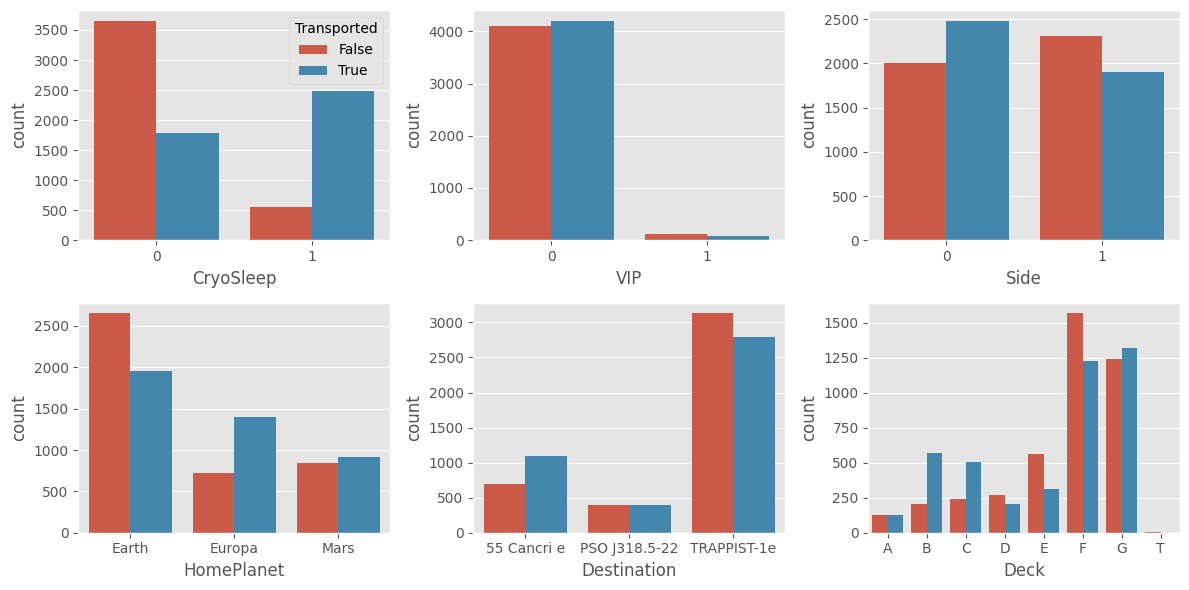

In [12]:
categorical_cols = ['CryoSleep','VIP', 'Side', 'HomePlanet','Destination','Deck']
n_rows = 2
n_cols = 3

fig,axs = plt.subplots(n_rows,n_cols,figsize=(4*n_cols,3*n_rows))
for i in range(n_rows):
    for j in range(n_cols):
        col_idx = n_cols*i+j 
        _ = sns.countplot(data=train,x=categorical_cols[col_idx],hue='Transported',ax=axs[i,j])
        if col_idx > 0:
            _ = axs[i,j].get_legend().remove()
fig.tight_layout()

In [13]:
# drop VIP
del train['VIP']
del test['VIP']

### Numerical columns

There are 6 numerical features. In the cell below, we plot the histograms of these features. 

- The `Age` feature is slightly right skewed, with the most commmon ages in the 20-30 bracket. Some of the passengers have age zero, which probably indicates these passengers are infants.
- The remaining features are heavily right skewed and have many 0 values. It make sense since these feature are the billings of the passengers at various ameneties - Passengers don't spend much. 

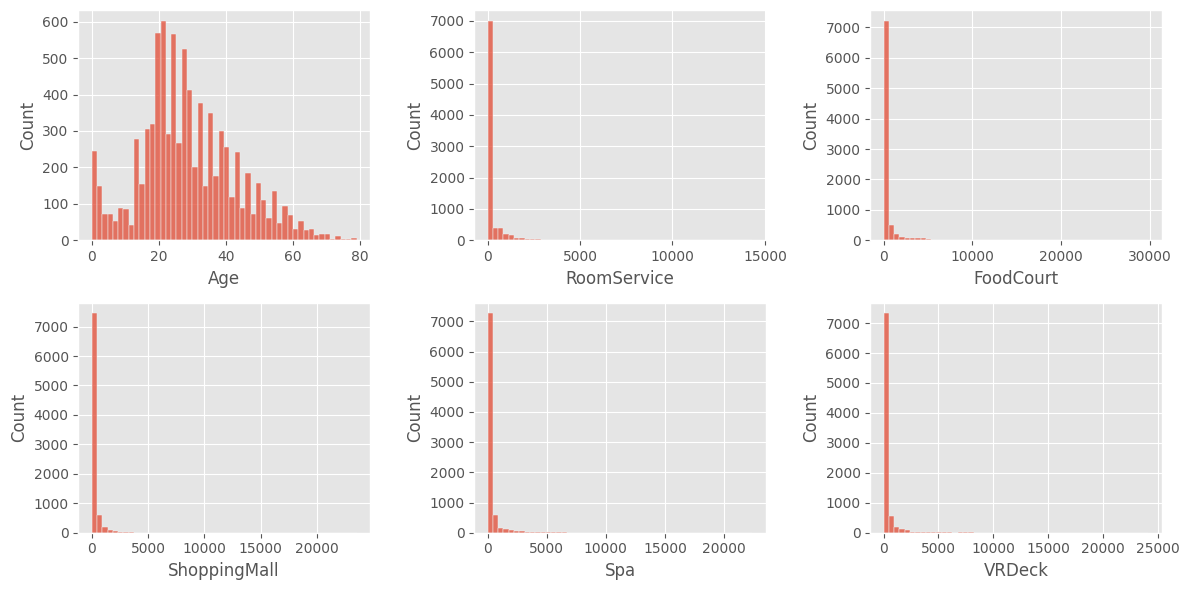

In [14]:
numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

n_rows = 2
n_cols = 3

fig,axs = plt.subplots(n_rows,n_cols,figsize=(4*n_cols,3*n_rows))
for i in range(n_rows):
    for j in range(n_cols):
        col_idx = n_cols*i+j 
        _ = sns.histplot(data=train,x=numerical_cols[col_idx],ax=axs[i,j],bins=50)
fig.tight_layout()

In the cell below, we show the boxplots of these numerical features grouped by the class. For features other than `Age`, we show the boxplot of the log1p transform for better clarity. 

- There seems to be no significant differences in Age between the two classes.
- There are some differences in the spending patterns at various ameneties between the two classes - passengers who were transported by and large do not spend much on amenities. However, there are many outliers in this class. 
- Among passengers who were not transported, the median spending is non-zero for RoomService, Spa, and VRDeck, and zero for the FoodCourt, and ShoppingMall. The former can be treated as luxury ameneties, while the latter can be treated as (somewhat) essential amenities.

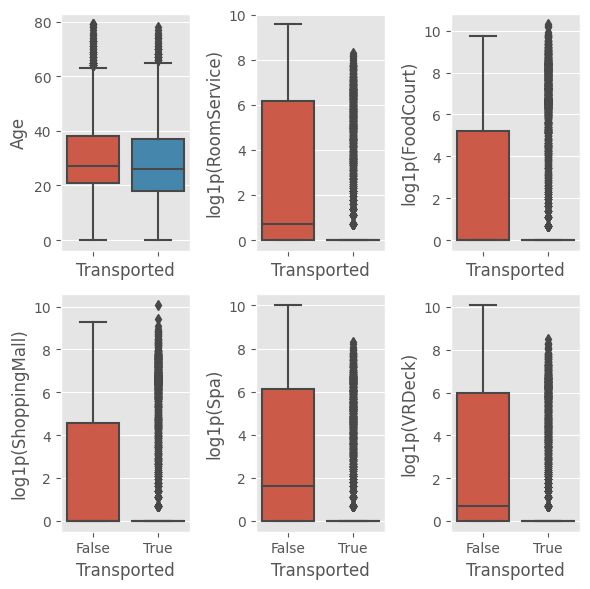

In [15]:
n_rows = 2
n_cols = 3

fig,axs = plt.subplots(n_rows,n_cols,figsize=(2*n_cols,3*n_rows),sharex=True)
for i in range(n_rows):
    for j in range(n_cols):
        column = numerical_cols[n_cols*i+j]
        if column == 'Age':
            _ = sns.boxplot(data=train,y=column,x='Transported',ax=axs[i,j])
        else:
            _ = sns.boxplot(y=np.log1p(train[column]),x=train['Transported'],ax=axs[i,j])
            _ = axs[i,j].set_ylabel(f'log1p({column})')
fig.tight_layout()

Finally, we plot a heatmap of the pairwise Spearman-rank correlations. There are no red flags here.

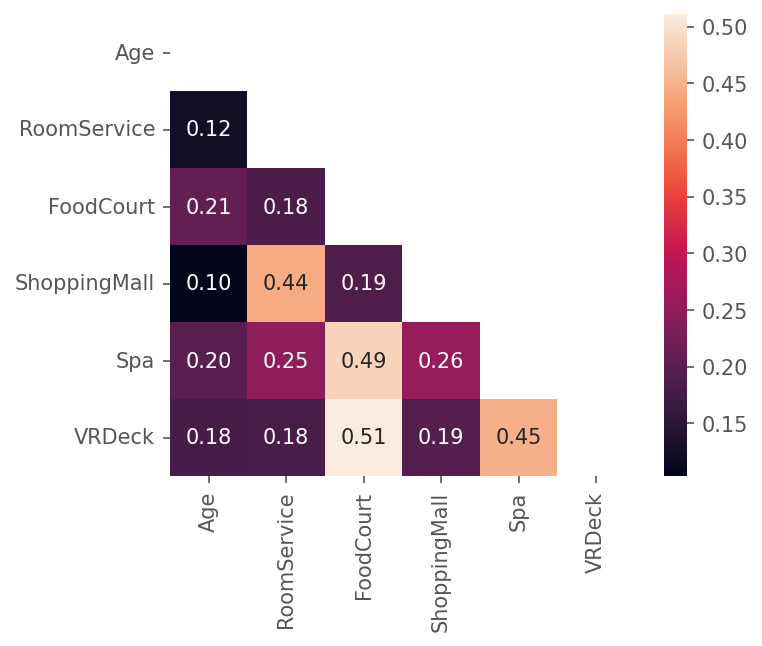

In [16]:
corr_matrix = train[numerical_cols].corr(method='spearman')
mask =np.triu(np.ones_like(corr_matrix, dtype=bool))
fig,ax = plt.subplots(1,1,figsize=(5,4),dpi=150)
_ = sns.heatmap(corr_matrix,annot=True,fmt='.2f',mask=mask,ax=ax)
_ = ax.set_facecolor('w')


## Handling missing values

In the quick snapshot earlier, we found that all the features have some values missing. In the cell below, I compute the fraction of missing values in each column. (Note: Columns with no missing values are excluded).

In [17]:
def filter_greater_than(series:pd.Series,threshold:Number) -> pd.Series:
    '''
    Returns series elements greater than threshold. This funtion can be
    used with the .pipe methods
    '''
    return series[series>threshold]

def get_perc_missing(df:pd.DataFrame) -> pd.Series:
    return (
        (df.isnull().sum()/df.shape[0]*100)
        .sort_values(ascending=False)
        .pipe(filter_greater_than,threshold=0)
        .round(3)
    )

perc_missing = get_perc_missing(train)
perc_missing

CryoSleep       2.496
ShoppingMall    2.393
HomePlanet      2.312
Deck            2.289
VRDeck          2.163
FoodCourt       2.105
Spa             2.105
Destination     2.094
RoomService     2.082
Age             2.059
dtype: float64

Among columns with missing values, the highest missing value percentage is just 2 percent. It might be tempting to drop the rows with missing entries. However, there are missing values in the test set too, as shown in the cell below. So, we will need an imputation strategy.

In [18]:
perc_missing_test = get_perc_missing(test)
perc_missing_test

FoodCourt       2.478
Spa             2.361
Deck            2.338
ShoppingMall    2.291
CryoSleep       2.174
Destination     2.151
Age             2.128
HomePlanet      2.034
RoomService     1.917
VRDeck          1.870
dtype: float64

For the numerical columns, I will impute the missing values with the median. For the remaining columns, I will impute the columns with the largest occuring entry. 

In [19]:
for column in perc_missing.index:
    if column in numerical_cols:
        # column is numerical valued
        # impute missing values with the median
        med_col = train[column].median()
        train[column] = train[column].fillna(med_col)
        test[column] = test[column].fillna(med_col)
    
    else:
        # column is categorical
        # impute missing values with the mode
        # if there are multiple modes - choose the first entry
        mode_col = train[column].mode().iloc[0]
        train[column] = train[column].fillna(mode_col)
        test[column] = test[column].fillna(mode_col)

## Feature engineering

From our previous analysis, we found that the expenses made by passengers at 5 different amenities have some relevance on whether they are transported or not. However, these features are very sparse and highly skewed since most passengers don't spend at all.

In the following, we create three additional features (2 numerical, and 1 binary)

1. `log1p_total_expenditure`: The total expenditure at all amenities followed by a log1p transform 
2. `'log1p_total_expenditure_luxury`: The total expenditure at the 3 luxury amenities followed by a log1p transform
3. `no_expenses`: If the passenger has incurred no expenses at these amenities. 

In [20]:
def new_expense_columns(df:pd.DataFrame) -> None:
    
    df['log1p_total_expenditure'] = np.log1p(df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1))
    df['log1p_total_expenditure_luxury'] = np.log1p(df[['RoomService','Spa', 'VRDeck']].sum(axis=1))
    df['no_expenses'] = 1*(df['log1p_total_expenditure']==0)
    
    
new_expense_columns(train)
new_expense_columns(test)    

Let's take a closer look at these new features. 

From the plot below, passengers with no expenses are much more likelier to be transported.

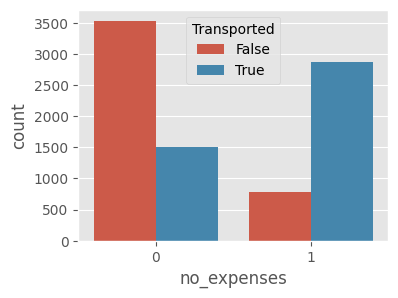

In [21]:
fig,ax = plt.subplots(1,1,figsize=(4,3))
_ = sns.countplot(data=train,x='no_expenses',hue='Transported',ax=ax)

In the cell below, we plot the histograms of the the 2 new numerical features. There is a clear pattern, especially for the total expenditure at luxury amenities: passengers who are not transported are likely to have large expenses. 

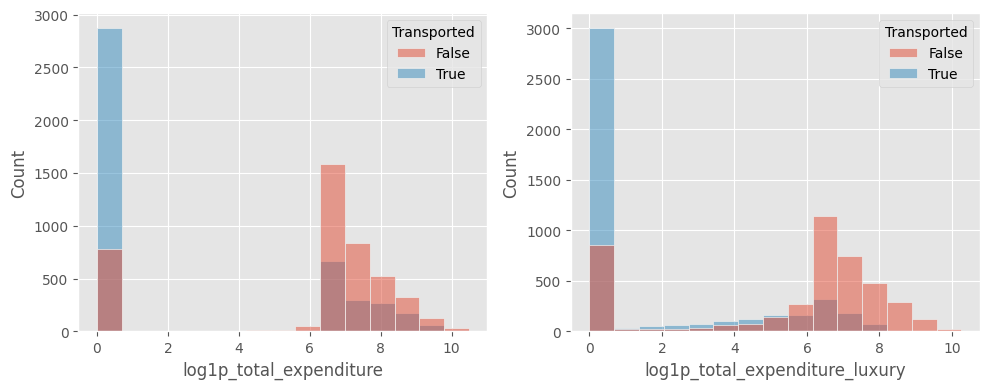

In [22]:
new_cols = ['log1p_total_expenditure', 'log1p_total_expenditure_luxury']
fig,axs = plt.subplots(1,len(new_cols),figsize=(5*len(new_cols),4))
for i in range(len(new_cols)):
    _ = sns.histplot(data=train,x=new_cols[i],hue='Transported',ax=axs[i],bins=15)
    #_ = axs[i].set_yscale('log')
fig.tight_layout()


Finally, we will drop the original expense features.

In [23]:
train = train.drop(['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'],axis=1)
test = test.drop(['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'],axis=1)

## Preparing the data for training

In [24]:

X = train.drop('Transported',axis=1)
y = 1*train['Transported'] # 1 if True 0 otherwise

## AutoML via FLaML

FLAML tunes both the type of estimator (e.g., xgboost, random forest, etc.) and the hyperparameters for each estimator simulataneosuly.

**Note**: In the AUTOML settings, I pass `"ensemble":True`. This means that the final model will be a stacked ensemble of the best models for each class.

In [25]:

automl = AutoML()
automl_settings = {
    "time_budget": 1200,  # total running time in seconds (20 minutes)
    "metric": 'accuracy', 
    "task": 'classification',  # task type
    "estimator_list":['lgbm', 'rf','xgboost', 'extra_tree', 'xgb_limitdepth'],
    "log_file_name": 'emissions_automl.log',
    "log_training_metric": True,  # whether to log training metric
    "keep_search_state": True, # needed if you want to keep the cross validation information
    "eval_method": "cv",
    "split_type": "stratified",
    "n_splits": 4,
    "ensemble":True,
}


with warnings.catch_warnings():
    # skips deprecation warnings from xgboost
    warnings.simplefilter("ignore")
    automl.fit(X,y,**automl_settings)

[flaml.automl.logger: 09-23 13:05:52] {1679} INFO - task = classification
[flaml.automl.logger: 09-23 13:05:52] {1690} INFO - Evaluation method: cv
[flaml.automl.logger: 09-23 13:05:52] {1788} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 09-23 13:05:52] {1900} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth']
[flaml.automl.logger: 09-23 13:05:52] {2218} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 09-23 13:05:52] {2344} INFO - Estimated sufficient time budget=2425s. Estimated necessary time budget=17s.
[flaml.automl.logger: 09-23 13:05:52] {2391} INFO -  at 0.3s,	estimator lgbm's best error=0.2323,	best estimator lgbm's best error=0.2323
[flaml.automl.logger: 09-23 13:05:52] {2218} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 09-23 13:05:52] {2391} INFO -  at 0.5s,	estimator lgbm's best error=0.2303,	best estimator lgbm's best error=0.2303
[flaml.automl.logger: 09-23 13:05:52] {221

Here are the best CV accuracies for each estimator type.

In [26]:
# best loss per estimator
(1-pd.Series(automl.best_loss_per_estimator)).sort_values(ascending=False)

lgbm              0.810537
xgboost           0.809386
xgb_limitdepth    0.807086
rf                0.804210
extra_tree        0.803635
dtype: float64

To get the corresponding configuration for each estimator. use the `.best_config_per_estimator` attribute

In [27]:
automl.best_config_per_estimator

{'lgbm': {'n_estimators': 16,
  'num_leaves': 47,
  'min_child_samples': 97,
  'learning_rate': 0.7341363166359363,
  'log_max_bin': 9,
  'colsample_bytree': 0.5632068230778601,
  'reg_alpha': 0.10158594098643202,
  'reg_lambda': 4.488714677059198},
 'rf': {'n_estimators': 47,
  'max_features': 0.6434007154873642,
  'max_leaves': 96,
  'criterion': 'entropy'},
 'xgboost': {'n_estimators': 1383,
  'max_leaves': 12,
  'min_child_weight': 0.20499107529765312,
  'learning_rate': 0.06732674769698947,
  'subsample': 1.0,
  'colsample_bylevel': 0.47300394758837233,
  'colsample_bytree': 0.5494148370982485,
  'reg_alpha': 0.15584230981871433,
  'reg_lambda': 0.04316365976594579},
 'extra_tree': {'n_estimators': 58,
  'max_features': 0.7792040059614167,
  'max_leaves': 165,
  'criterion': 'entropy'},
 'xgb_limitdepth': {'n_estimators': 12,
  'max_depth': 4,
  'min_child_weight': 19.877934106784924,
  'learning_rate': 0.9052878242454832,
  'subsample': 1.0,
  'colsample_bylevel': 0.6344573960475

As mentioned earlier, the final model will be a stacked ensemble of the best models for each class of models.

In [28]:
automl.model

StackingClassifier(estimators=[('lgbm',
                                <flaml.automl.model.LGBMEstimator object at 0x7bbe06114760>),
                               ('xgboost',
                                <flaml.automl.model.XGBoostSklearnEstimator object at 0x7bbe061c1c30>),
                               ('xgb_limitdepth',
                                <flaml.automl.model.XGBoostLimitDepthEstimator object at 0x7bbe061c1150>),
                               ('rf',
                                <flaml.automl.model.RandomForestEstimator object at 0x7bbe067ac5b0>),
                               ('extra_tree',
                                <flaml.automl.model.ExtraTreesEstimator object at 0x7bbe067ad0f0>)],
                   n_jobs=-1)

In [29]:
# save model
import pickle
with open('automl_space_titanic.pkl', 'wb') as f:
    pickle.dump(automl, f, pickle.HIGHEST_PROTOCOL)

## Test predictions

In [30]:
submission = pd.DataFrame({
    'PassengerId':test.index.values,
    'Transported':automl.predict(test).astype(bool)
})
submission.to_csv('submission.csv',index=False)

In [31]:
# percentage of true predictions
print(f"Percentage of true predictions {(submission['Transported'].sum()/submission.shape[0]*100):.2f}")

Percentage of true predictions 53.87
